In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pprint

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/data.csv')
df_org = pd.read_csv('/content/drive/MyDrive/data.csv')

In [ ]:
df.head(5)

,type_school,school_accreditation,gender,interest,residence,parent_age,parent_salary,house_area,average_grades,parent_was_in_college,will_go_to_college
0,Academic,A,Male,Less Interested,Urban,56,6950000,83.0,84.09,False,True
1,Academic,A,Male,Less Interested,Urban,57,4410000,76.8,86.91,False,True
2,Academic,B,Female,Very Interested,Urban,50,6500000,80.6,87.43,False,True
3,Vocational,B,Male,Very Interested,Rural,49,6600000,78.2,82.12,True,True
4,Academic,A,Female,Very Interested,Urban,57,5250000,75.1,86.79,False,False


In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

type_school              0
school_accreditation     0
gender                   0
interest                 0
residence                0
parent_age               0
parent_salary            0
house_area               0
average_grades           0
parent_was_in_college    0
will_go_to_college       0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_hot = pd.get_dummies(df)
df_scaled = pd.DataFrame(scaler.fit_transform(df_hot), columns = df_hot.columns)
df_hot.describe()

,parent_age,parent_salary,house_area,average_grades
count,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,52.208000,5.381570e+06,74.515300,86.097200
std,3.500427,1.397546e+06,15.293346,3.378738
min,40.000000,1.000000e+06,20.000000,75.000000
25%,50.000000,4.360000e+06,64.600000,83.737500
50%,52.000000,5.440000e+06,75.500000,85.575000
75%,54.000000,6.382500e+06,84.825000,88.262500
max,65.000000,1.000000e+07,120.000000,98.000000


In [ ]:
df_scaled.head(5)

,parent_age,parent_salary,house_area,average_grades,parent_was_in_college,will_go_to_college,type_school_Academic,type_school_Vocational,school_accreditation_A,school_accreditation_B,gender_Female,gender_Male,interest_Interested,interest_Less Interested,interest_Not Interested,interest_Uncertain,interest_Very Interested,residence_Rural,residence_Urban
0,1.083838,1.122836,0.555074,-0.594365,-1.040833,1.0,0.801272,-0.801272,1.038750,-1.038750,-0.970437,0.970437,-0.333333,1.834888,-0.306744,-0.594289,-0.692308,-0.924818,0.924818
1,1.369661,-0.695545,0.149467,0.240684,-1.040833,1.0,0.801272,-0.801272,1.038750,-1.038750,-0.970437,0.970437,-0.333333,1.834888,-0.306744,-0.594289,-0.692308,-0.924818,0.924818
2,-0.631096,0.800682,0.398065,0.394664,-1.040833,1.0,0.801272,-0.801272,-0.962695,0.962695,1.030464,-1.030464,-0.333333,-0.544993,-0.306744,-0.594289,1.444444,-0.924818,0.924818
3,-0.916918,0.872272,0.241055,-1.177715,0.960769,1.0,-1.248016,1.248016,-0.962695,0.962695,-0.970437,0.970437,-0.333333,-0.544993,-0.306744,-0.594289,1.444444,1.081294,-1.081294
4,1.369661,-0.094191,0.038251,0.205150,-1.040833,-1.0,0.801272,-0.801272,1.038750,-1.038750,1.030464,-1.030464,-0.333333,-0.544993,-0.306744,-0.594289,1.444444,-0.924818,0.924818


In [ ]:
for col in ['parent_age', 'parent_salary', 'house_area', 'average_grades']:
    df[col] = pd.cut(df[col], bins=4, labels=False)

df.head()

,type_school,school_accreditation,gender,interest,residence,parent_age,parent_salary,house_area,average_grades,parent_was_in_college,will_go_to_college
0,Academic,A,Male,Less Interested,Urban,2,2,2,1,False,True
1,Academic,A,Male,Less Interested,Urban,2,1,2,2,False,True
2,Academic,B,Female,Very Interested,Urban,1,2,2,2,False,True
3,Vocational,B,Male,Very Interested,Rural,1,2,2,1,True,True
4,Academic,A,Female,Very Interested,Urban,2,1,2,2,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df
Y = df.iloc[:,-1 ]
train, test, _ ,_ = train_test_split(X, Y, test_size = 0.15,random_state = 78 )

print('Train lenght', len(train))
print('Test lenght', len(test))

Train lenght 850
Test lenght 150


In [ ]:
#function to calculate entropy
def entropy(data, label = 'will_go_to_college' ):
    counts = data[label].value_counts()
    total = len(data)
    entropy = 0

    for value in counts:
        prob = value/ total
        entropy = entropy - prob * np.log2(prob)

    return entropy


#Calculate information gain
def cal_info_gain(data):
    base_entropy = entropy(data)
    total = len(data)

    info_gain =[]

    for column in data.columns[:-1]:

        attribute_values = data[column].unique()
        new_entropy = 0.0


        for value in attribute_values:
            subset = data[data[column] == value]
            prob = len(subset)/total
            new_entropy += prob*entropy(subset)

        info_gain.append([column, base_entropy-new_entropy])

    return info_gain

print(cal_info_gain(df))

[['type_school', np.float64(0.0008756968251206754)], ['school_accreditation', np.float64(0.0006502498518179411)], ['gender', np.float64(0.0008347905049521653)], ['interest', np.float64(0.05521813009236798)], ['residence', np.float64(2.6127631853833932e-05)], ['parent_age', np.float64(0.007837867136231691)], ['parent_salary', np.float64(0.1481582697143876)], ['house_area', np.float64(0.14960114272715186)], ['average_grades', np.float64(0.22919509734104793)], ['parent_was_in_college', np.float64(0.0016652930806921873)]]


In [ ]:
#Recursively build the tree

def build_tree_ID3(data, root=None):
    global split_info
    label = 'will_go_to_college'

    info_gain = cal_info_gain(data)
    info_gain = sorted(info_gain, key=lambda x: x[1], reverse=True)
    column_name = info_gain[0][0]


    root = {column_name: {}}

    for attr in data[column_name].unique():

        new_data = data[data[column_name] == attr]
        new_data = new_data.drop(column_name, axis=1)

        if len(new_data.columns) < 2:
            count = new_data[label].value_counts()
            count = count.sort_values(ascending=False)
            root[column_name][attr] = count.index[0]

        elif len(new_data) > 1 and len(new_data[label].unique()) > 1:
            new = build_tree_ID3(new_data, root)
            root[column_name][attr] = new

        else:
            output = new_data[label].unique()
            root[column_name][attr] = output[0]

    return root

In [ ]:
def print_tree(tree, indent=0):
    """
    Recursively prints the decision tree dictionary in a readable format.
    """
    for key, value in tree.items():
        # Print the node (column name)
        print('  ' * indent + f"[{key}]")

        for attr, subtree in value.items():
            # Print each branch
            if isinstance(subtree, dict):
                print('  ' * (indent + 1) + f"({attr}) ➜")
                print_tree(subtree, indent + 2)  # Recursive call
            else:
                print('  ' * (indent + 1) + f"({attr}) ➜ {subtree}")


In [ ]:
id3_tree = build_tree_ID3(df)
print_tree(id3_tree)

[average_grades]
  (1) ➜
    [parent_salary]
      (2) ➜
        [house_area]
          (2) ➜
            [residence]
              (Urban) ➜
                [type_school]
                  (Academic) ➜
                    [parent_was_in_college]
                      (False) ➜
                        [school_accreditation]
                          (A) ➜
                            [interest]
                              (Less Interested) ➜
                                [parent_age]
                                  (2) ➜
                                    [gender]
                                      (Male) ➜ True
                                      (Female) ➜ True
                                  (1) ➜
                                    [gender]
                                      (Male) ➜ False
                                      (Female) ➜ True
                              (Interested) ➜
                                [gender]
                                  (Male

In [ ]:
#Calculate gain
def Gain(data):
    base_entropy = entropy(data)
    total = len(data)

    gain =[]

    for column in data.columns[:-1]:

        attribute_values = data[column].unique()
        new_entropy = 0.0


        for value in attribute_values:
            subset = data[data[column] == value]
            prob = len(subset)/total
            new_entropy += prob*entropy(subset)

        gain.append([column, base_entropy-new_entropy])

    return gain

In [ ]:
# implementation of c4.5

def split_info(data):
    total = len(data)

    split_info_ =[]

    for column in data.columns[:-1]:

        attribute_values = data[column].unique()
        split_info_att = 0.0


        for value in attribute_values:
            subset = data[data[column] == value]
            prob = len(subset)/total
            split_info_att -= prob * np.log2(prob)

        split_info_.append([column, split_info_att])

    return split_info_


#gainratio = gain/splitinfo
def gain_ratio(data):
    gain = Gain(data)
    splitinfo = split_info(data)
    gain = np.array(gain)
    splitinfo = np.array(splitinfo)

    gain_ratio_ = list()

    for a, b in zip(gain, splitinfo):
        if float(b[1])==0:
            ratio =0
        else:
            ratio = float(a[1])/float(b[1])

        gain_ratio_.append([a[0], ratio])

    return gain_ratio_

In [ ]:
#Recursively build the tree and store

split_information = []
def build_tree_C4_5(data, root=None):
    global split_info
    label = 'will_go_to_college'

    gain_ratio_ = gain_ratio(data)
    gain_ratio_ = sorted(gain_ratio_, key=lambda x: x[1], reverse=True)
    column_name = gain_ratio_[0][0]

    split_information.append(column_name)
    root = {column_name: {}}

    for attr in data[column_name].unique():

        new_data = data[data[column_name] == attr]
        new_data = new_data.drop(column_name, axis=1)

        if len(new_data.columns) < 2:
            count = new_data[label].value_counts()
            count = count.sort_values(ascending=False)
            root[column_name][attr] = count.index[0]

        elif len(new_data) > 1 and len(new_data[label].unique()) > 1:
            new = build_tree_C4_5(new_data, root)
            root[column_name][attr] = new

        else:
            output = new_data[label].unique()
            root[column_name][attr] = output[0]

    return root

In [ ]:
c4_5_tree = build_tree_C4_5(df)
print_tree(c4_5_tree)

[average_grades]
  (1) ➜
    [parent_salary]
      (2) ➜
        [house_area]
          (2) ➜
            [residence]
              (Urban) ➜
                [type_school]
                  (Academic) ➜
                    [parent_was_in_college]
                      (False) ➜
                        [school_accreditation]
                          (A) ➜
                            [gender]
                              (Male) ➜
                                [interest]
                                  (Less Interested) ➜
                                    [parent_age]
                                      (2) ➜ True
                                      (1) ➜ False
                                  (Interested) ➜ False
                                  (Very Interested) ➜
                                    [parent_age]
                                      (1) ➜ True
                              (Female) ➜
                                [parent_age]
                            

In [ ]:
#Make decision using the tree
def predict_decision_tree(data_point, decision_tree):
    node = decision_tree
    default_prediction = False

    while isinstance(node, dict):
        feature = list(node.keys())[0]
        value = data_point[feature]

        if value is None:
            return default_prediction

        try:
            node = node[feature][value]
        except KeyError:
            return default_prediction

    return node

In [ ]:
#Functions for evaluation of model


def generate_report(data, tree):
    predictions = []
    actual = data.iloc[:, -1]
    for index, row in data.iterrows():
        row = row.drop('will_go_to_college', axis = 0)
        pre = predict_decision_tree(row, tree)
        predictions.append(pre)


    report = classification_report(actual, predictions)
    matrix = confusion_matrix(actual, predictions)

    return report, matrix


def plot_matrix(matrix):
    labels= [False, True]
    sns.heatmap(matrix, annot = True, fmt=".2f",cmap='Greens', xticklabels = labels, yticklabels = labels)
    plt.xlabel('Prediction')
    plt.ylabel('Ground Truth')
    plt.show()


Train Report

              precision    recall  f1-score   support

       False       0.96      0.97      0.97       418
        True       0.97      0.96      0.97       432

    accuracy                           0.97       850
   macro avg       0.97      0.97      0.97       850
weighted avg       0.97      0.97      0.97       850



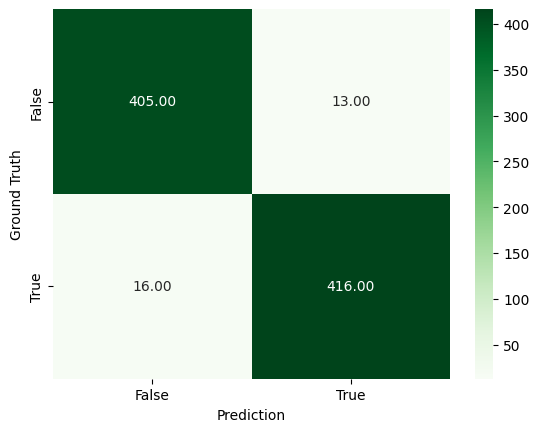


 Test Report

              precision    recall  f1-score   support

       False       0.89      0.93      0.91        82
        True       0.91      0.87      0.89        68

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150



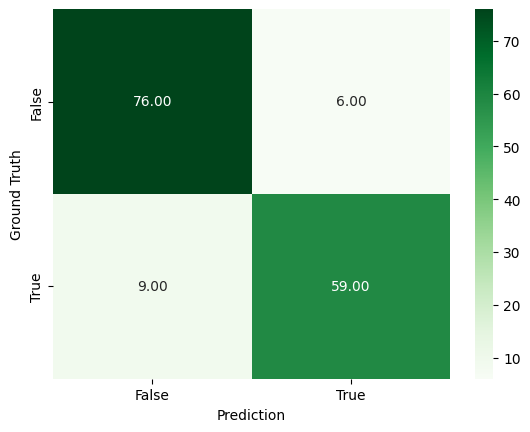

In [ ]:
#Training

id3_tree = build_tree_ID3(train)

# Train report
report, matrix = generate_report(train, id3_tree)
print('\nTrain Report\n')
print(report)
plot_matrix(matrix)


# Test report
report, matrix = generate_report(test, id3_tree)
print('\n Test Report\n')
print(report)
plot_matrix(matrix)


Train Report

              precision    recall  f1-score   support

       False       0.96      0.97      0.97       418
        True       0.97      0.96      0.97       432

    accuracy                           0.97       850
   macro avg       0.97      0.97      0.97       850
weighted avg       0.97      0.97      0.97       850



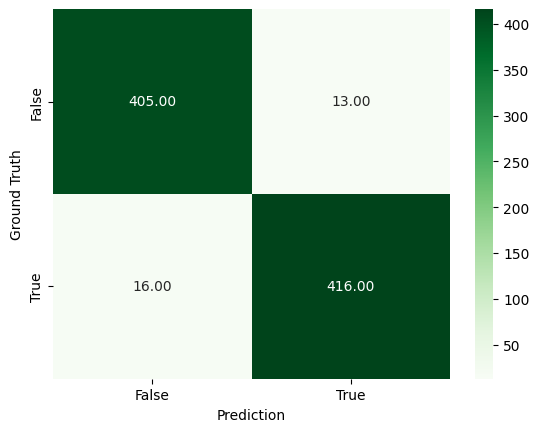


 Test Report

              precision    recall  f1-score   support

       False       0.90      0.93      0.92        82
        True       0.91      0.88      0.90        68

    accuracy                           0.91       150
   macro avg       0.91      0.90      0.91       150
weighted avg       0.91      0.91      0.91       150



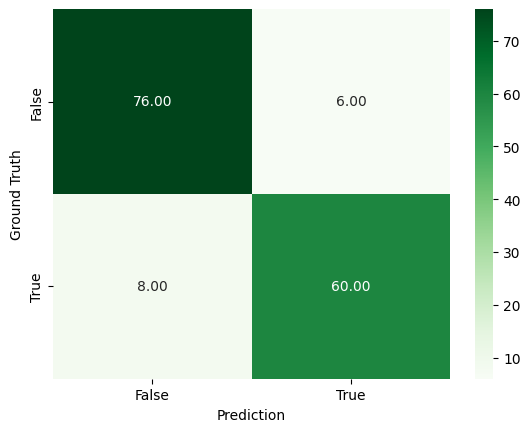

In [ ]:
#Training c4.5

c4_5_tree = build_tree_C4_5(train)

# Train report
report, matrix = generate_report(train, c4_5_tree)
print('\nTrain Report\n')
print(report)
plot_matrix(matrix)


# Test report
report, matrix = generate_report(test, c4_5_tree)
print('\n Test Report\n')
print(report)
plot_matrix(matrix)

In [ ]:
def accuracy(data, tree):
    predictions = []
    actual = data.iloc[:, -1]
    for index, row in data.iterrows():
        row = row.drop('will_go_to_college', axis = 0)
        pre = predict_decision_tree(row, tree)
        predictions.append(pre)

    predictions = np.array(predictions)
    accu = (predictions==actual).sum()/actual.shape[0]
    return accu

In [ ]:
seed_data = []
for i in range(1, 50):
    '''
    seed_data = ['seed', 'id3_acc', 'c4.5_acc']
    '''

    X = df
    Y = df.iloc[:,-1 ]
    train, test, _ ,_ = train_test_split(X, Y, test_size = 0.1,random_state = i )

    id3_tree = build_tree_ID3(train)
    c4_5_tree = build_tree_C4_5(train)

    accu_id3 = accuracy(test, id3_tree)
    accu_c4 = accuracy(test, c4_5_tree)
    seed_data.append([i, accu_id3,accu_c4 ])

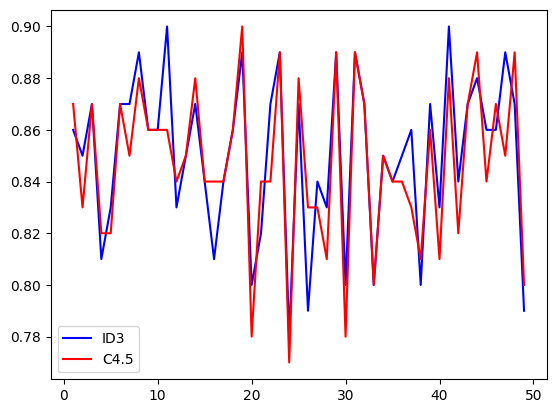

In [ ]:
seed_data = np.array(seed_data)
plt.plot(seed_data[:, 0], seed_data[:, 1], color = 'blue')
plt.plot(seed_data[:, 0], seed_data[:, 2], color = 'red')
plt.legend(['ID3', 'C4.5'])
plt.show()

In [ ]:
seed_data[:, 1].mean(),  seed_data[:, 2].mean()


(np.float64(0.8502040816326532), np.float64(0.846734693877551))

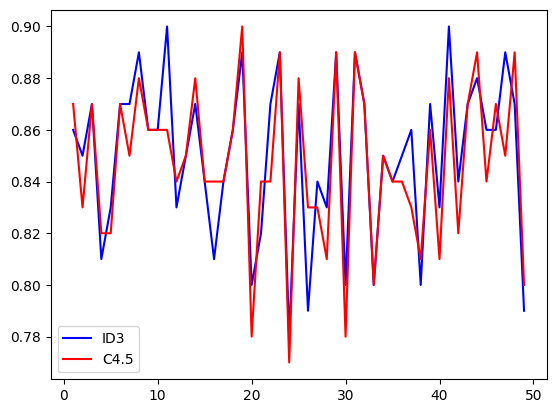

In [ ]:
plt.plot(seed_data[:, 0], seed_data[:, 1], color = 'blue')
plt.plot(seed_data[:, 0], seed_data[:, 2], color = 'red')
plt.legend(['ID3', 'C4.5'])
plt.show()

In [ ]:
 seed_data[:, 1].mean()

np.float64(0.8502040816326532)

In [ ]:
 seed_data[:, 2].mean()

np.float64(0.846734693877551)